## Step 1: Import Required Libraries

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Step 2: Load and Explore the Dataset

In [18]:
df = pd.read_csv("bmw_cars.csv")
df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   car_id                        10000 non-null  int64  
 1   model                         10000 non-null  str    
 2   year                          10000 non-null  int64  
 3   engine_size                   9757 non-null   float64
 4   horsepower                    10000 non-null  int64  
 5   fuel_type                     10000 non-null  str    
 6   transmission                  9785 non-null   str    
 7   drivetrain                    10000 non-null  str    
 8   mileage_km                    10000 non-null  int64  
 9   fuel_consumption_l_per_100km  9754 non-null   float64
 10  co2_emissions_g_km            9775 non-null   float64
 11  price_usd                     10000 non-null  int64  
 12  doors                         10000 non-null  int64  
 13  seats        

car_id                            0
model                             0
year                              0
engine_size                     243
horsepower                        0
fuel_type                         0
transmission                    215
drivetrain                        0
mileage_km                        0
fuel_consumption_l_per_100km    246
co2_emissions_g_km              225
price_usd                         0
doors                             0
seats                             0
body_type                         0
color                           239
owner_count                     255
accident_history                254
service_history                 231
country_sold                      0
dtype: int64

## Step 3: Data Cleaning

In [19]:
## Fill numeric missing values with mean
df['engine_size']= df['engine_size'].fillna(df['engine_size'].mean())
df['fuel_consumption_l_per_100km']= df['fuel_consumption_l_per_100km'].fillna(df['fuel_consumption_l_per_100km'].mean())
df['co2_emissions_g_km']= df['co2_emissions_g_km'].fillna(df['co2_emissions_g_km'].mean())
df['owner_count']= df['owner_count'].fillna(df['owner_count'].mean())

## Clean Categorical Columns
df['transmission']= df['transmission'].fillna("Unknown")
df['color']= df['color'].fillna("Unknown")
df['accident_history']= df['accident_history'].fillna("Unknown")
df['service_history']= df['service_history'].fillna("Unknown")
df.isnull().sum()

car_id                          0
model                           0
year                            0
engine_size                     0
horsepower                      0
fuel_type                       0
transmission                    0
drivetrain                      0
mileage_km                      0
fuel_consumption_l_per_100km    0
co2_emissions_g_km              0
price_usd                       0
doors                           0
seats                           0
body_type                       0
color                           0
owner_count                     0
accident_history                0
service_history                 0
country_sold                    0
dtype: int64

## Step 4: Count Cars by Model

In [20]:
df['model'].value_counts()
# Average price by model
df.groupby('model')['price_usd'].mean().sort_values(ascending=False)

model
i7          137286.527439
X7           95336.053055
7 Series     87195.972222
X5           66704.311010
i4           62766.140436
Z4           50740.862069
5 Series     47352.191011
X3           46611.075456
i3           42267.414758
X1           32718.482629
3 Series     30960.015990
1 Series     20346.993014
Name: price_usd, dtype: float64

## Step 5: Count cars by Fuel Type

In [21]:
df['fuel_type'].value_counts()
# Average price by fuel type
df.groupby('fuel_type')['price_usd'].mean()

fuel_type
diesel      46752.887191
electric    79433.685803
hybrid      46462.850953
petrol      46672.544431
Name: price_usd, dtype: float64

## Step 6: Cars Sold by Country

In [22]:
df['country_sold'].value_counts()

country_sold
Spain          1356
France         1269
UK             1253
Turkey         1246
Netherlands    1238
Italy          1238
USA            1228
Germany        1172
Name: count, dtype: int64

## Step 7: Accident History Analysis

In [23]:
df['accident_history'].value_counts()
# Whether accidents affect car price
df.groupby('accident_history')['price_usd'].mean()

accident_history
Unknown    53083.421260
no         54958.403261
yes        38416.818627
Name: price_usd, dtype: float64

## Step 8: Advanced Visualizations

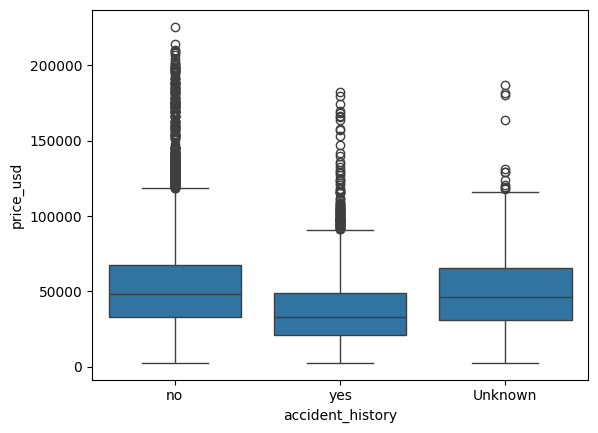

In [24]:
import seaborn as sns
sns.boxplot(x ='accident_history', y= 'price_usd',data=df)
plt.title= (" Impact of Accident History on car price")
plt.show()

## Step 9: Model Distribution 

TypeError: 'str' object is not callable

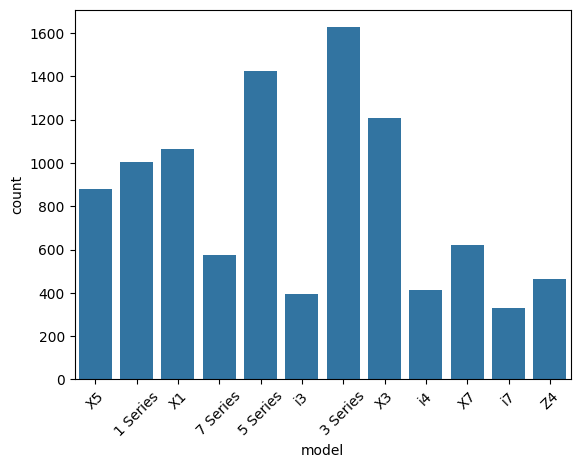

In [25]:

sns.countplot(x= 'model', data= df)
plt.xticks(rotation= 45)
plt.title('BMW Cars Distribution')
plt.show()

## Step 10: Price Distribution

TypeError: 'str' object is not callable

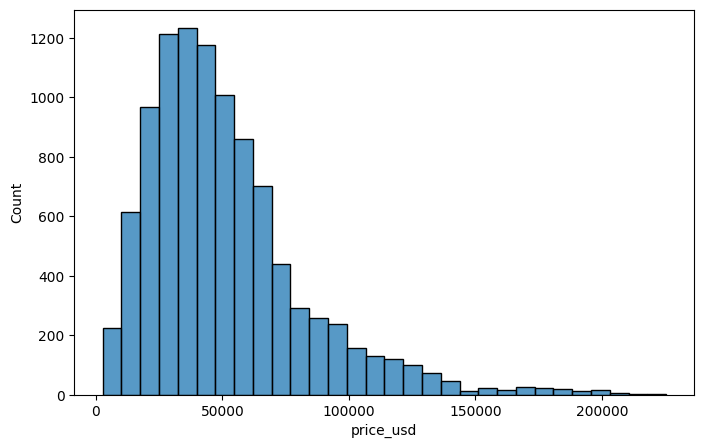

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df['price_usd'], bins = 30)
plt.title("Distribution of BMW Car Prices")
plt.xlabel("price(USD)")
plt.ylabel("Number of cars")
plt.show()

## Step 11: Mileage and Price

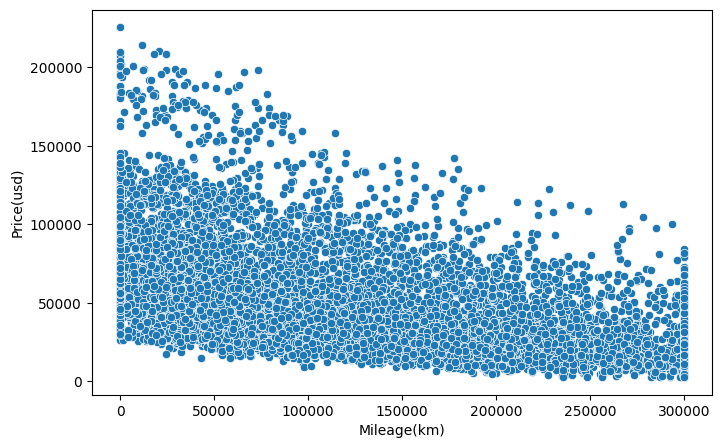

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(x= 'mileage_km', y= 'price_usd', data=df)
plt.title= ("Relashionship betweem Mileage and price")
plt.xlabel("Mileage(km)")
plt.ylabel("Price(usd)")
plt.show()

## Step 12: Correlation Heatmap

TypeError: 'str' object is not callable

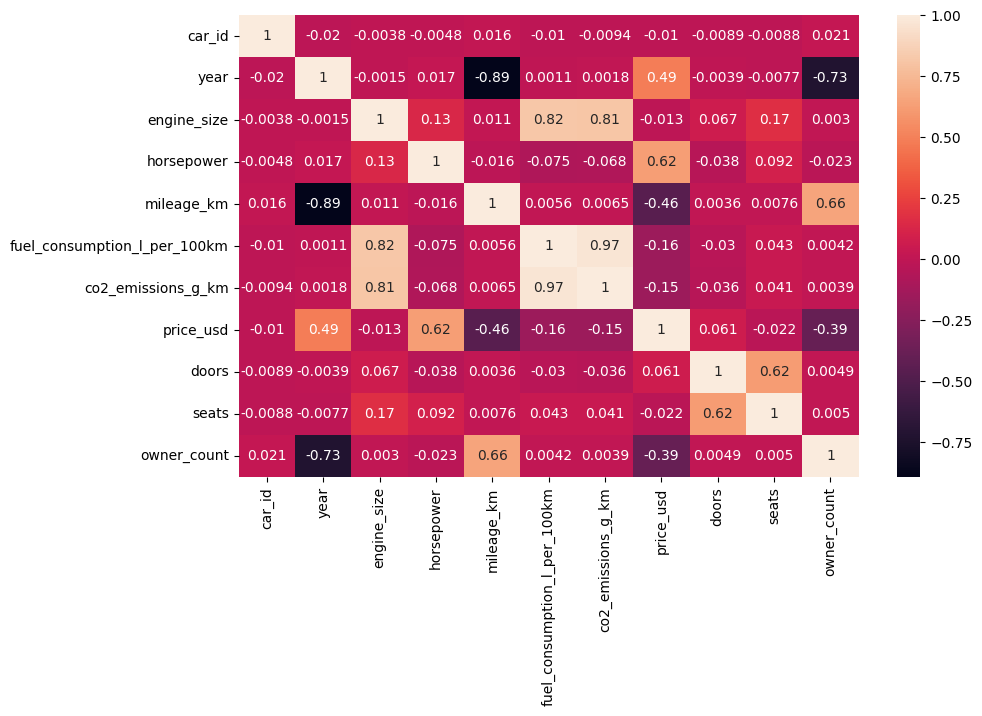

In [32]:
plt.figure(figsize=(10,6))
corr= df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlaton between Numerical variables")
plt.show()